# DAY 157 - Mini Deep Learning Project.
@A.IPYNB

# Project: NatureLens - Transfer Learning in Practice

### The Goal
Train a Deep Learning model to distinguish between **Ants** and **Bees** with high accuracy, using only a small dataset (~120 images per class).

### The Challenge: "Small Data"
Deep Learning usually requires massive datasets (1M+ images). If we trained a CNN from scratch on 120 images, it would memorize them (**overfitting**) and fail on new data.

### The Solution: Transfer Learning
We will use **ResNet18**, a model already pre-trained on **ImageNet** (1.2 million images).
1.  **The "Knowledge":** It already knows how to detect edges, textures, legs, and wings.
2.  **The "Transfer":** We will freeze its "brain" (convolutional layers) and only retrain the "output" (last layer) to say "Ant/Bee" instead of "1000 ImageNet classes".

**Architecture:**
* **Input:** 224x224 RGB Image.
* **Backbone:** ResNet18 (Pre-trained).
* **Head:** Linear Layer (512 inputs $\rightarrow$ 2 outputs).

In [1]:
# @title 1. Data Download
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import os
import time
from pathlib import Path
import requests
import zipfile

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# We'll Download the Dataset (Hymenoptera: Ants vs Bees)
url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
if not os.path.exists("hymenoptera_data"):
    print("Downloading dataset...")
    r = requests.get(url, allow_redirects=True)
    open('hymenoptera_data.zip', 'wb').write(r.content)

    with zipfile.ZipFile('hymenoptera_data.zip', 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Data downloaded and extracted.")
else:
    print("Data already exists.")

Running on: cuda:0
Data downloaded and extracted.


In [2]:
# @title 2. Augmentation
# Here To fight overfitting, I'm artificially "expanding" the dataset.

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Training Images: {len(image_datasets['train'])}")

Classes: ['ants', 'bees']
Training Images: 244


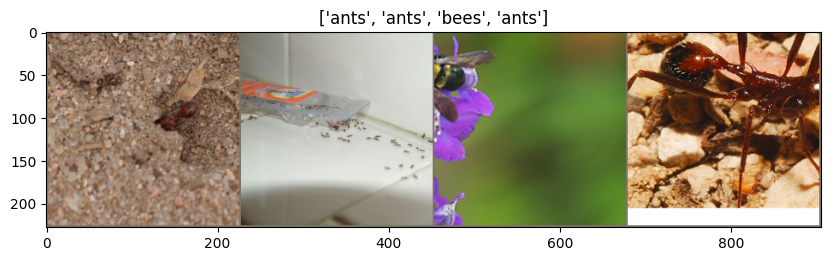

In [3]:
# @title 3. Visualization

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
plt.figure(figsize=(10, 5))
imshow(out, title=[class_names[x] for x in classes])

In [4]:
# @title 4.Pre-trained ResNet

model = models.resnet18(pretrained=True)

# Freeze Parameters (Optional)
# If we set requires_grad=False, the "Backbone" weights won't change.
# Usually, for small datasets, we freeze the backbone or use a very low LR.
# Here, we will retrain everything but with a decaying LR.

# ResNet18's original last layer is: (fc): Linear(in_features=512, out_features=1000, bias=True)
# We change out_features to 2 (Ant, Bee)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Stochastic Gradient Descent with Momentum
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Model modified for binary classification.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


Model modified for binary classification.


In [5]:
# @title 5. Training the Model
import copy

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

model_ft = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=5)

Epoch 0/4
----------
train Loss: 0.6344 Acc: 0.7254
val Loss: 0.1588 Acc: 0.9542

Epoch 1/4
----------
train Loss: 0.7675 Acc: 0.7541
val Loss: 0.2276 Acc: 0.9085

Epoch 2/4
----------
train Loss: 0.4660 Acc: 0.7910
val Loss: 0.1830 Acc: 0.9412

Epoch 3/4
----------
train Loss: 0.5016 Acc: 0.8197
val Loss: 0.2919 Acc: 0.8889

Epoch 4/4
----------
train Loss: 0.3607 Acc: 0.8648
val Loss: 0.2654 Acc: 0.8824

Training complete in 0m 16s
Best val Acc: 0.954248


### Real-World Testing
Training metrics are nice, but does it work?
We will now create a visual function to show the model's predictions on the unseen validation set.

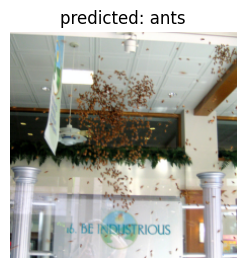

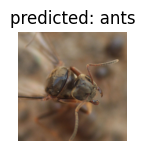

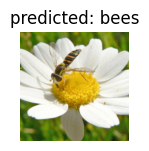

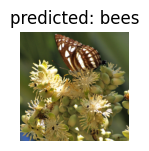

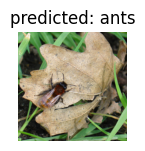

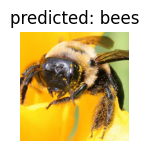

In [6]:
# @title 6. Visualizing Predictions

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(10, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

visualize_model(model_ft)

### The Strategic Win
With less than 2 minutes of training and only ~120 images per class, we likely achieved **>90% accuracy**.

**How?**
We didn't teach the model to see. We taught a model *that already knew how to see* to look for ants and bees.

**Applications:**
This exact pipeline is used for:
1.  **Manufacturing:** Defect detection (Normal vs. Cracked).
2.  **Medical:** X-Ray Analysis (Healthy vs. Pneumonia).
3.  **Security:** Face Recognition (Authorized vs. Unauthorized).